In [1]:
%matplotlib inline

Matplotlib is building the font cache; this may take a moment.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

Let's check that we have the ellipticity Jacobian right. Since $h_0 \propto \epsilon / D$ we must have that

$$
p(\epsilon, D) = p(h_0, D) \left| \frac{\partial h_0}{\partial \epsilon} \right| = p\left[h_0(\epsilon, D), D\right] \frac{1}{D}
$$

This means that, if we want a prior that is uniform in $(\epsilon, D)$, then a uniform distribution in $(h_0, D)$ must be multiplied by a Jacobian factor $\propto D$. Let's check numerically that that's correct.

First, produce uniform samples in $(h_0, D)$ and display them:

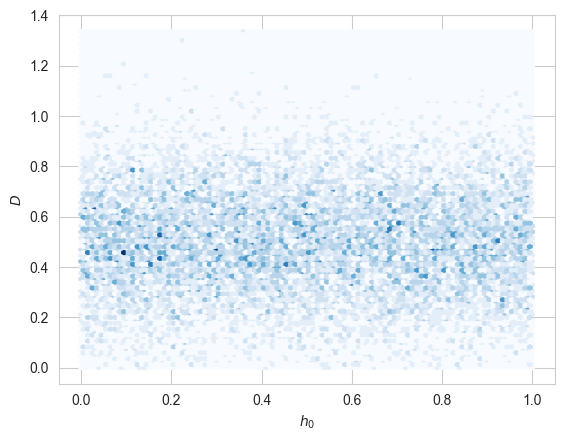

In [2]:
# simulate sampling flat in h0 and D
h0 = np.random.uniform(0, 1, 10000)
D = np.random.normal(0.5,0.2,10000)
D = np.absolute(D)

# 2D hexbin plot of h0 and D
plt.hexbin(h0, D, gridsize=100, cmap='Blues')
plt.xlabel(r'$h_0$')
plt.ylabel(r'$D$');

Next derive $\epsilon$ for each $h0$ and $D$. The resulting distribution will not be uniform in $(\epsilon, D)$, but rather $\propto 1/D$

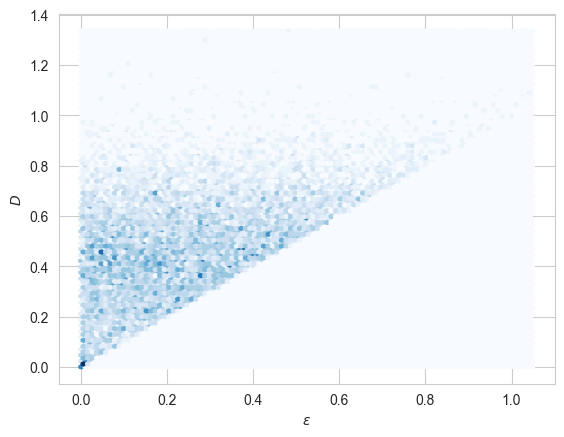

In [3]:
# compute epsilon from h0 and D
epsilon = h0 * D

# 2D hexbin plot of epsilon and D
plt.hexbin(epsilon, D, gridsize=100, cmap='Blues')
plt.xlabel(r'$\epsilon$')
plt.ylabel(r'$D$');

We can reweight the above by a $D$ factor, to restore uniformity in the joint $(\epsilon, D)$ distribution:

[4077 6431 3352 ... 6909 2751 7397]


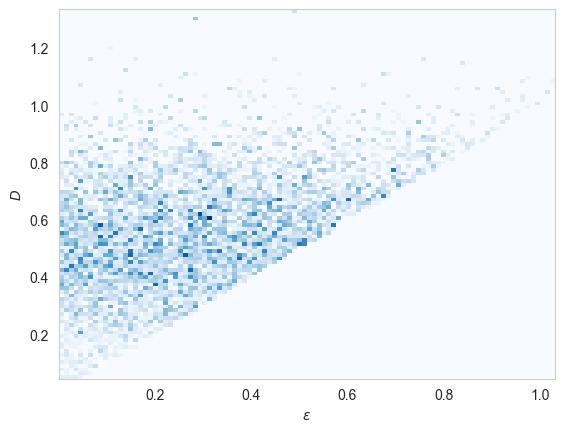

In [5]:
# resample per the Jacobian 1/D
w = D
idxs = np.random.choice(len(epsilon), size=len(epsilon), p=w / np.sum(w))
print(idxs)
# 2D histogram of epsilon and D
plt.hist2d(epsilon[idxs], D[idxs], bins=100, cmap='Blues')
plt.xlabel(r'$\epsilon$')
plt.ylabel(r'$D$');